# Global Happiness Report Analysis

Analyzing the World Happiness Report data to understand what factors contribute to happiness in different countries. Visualizing correlations between happiness scores and variables such as GDP per capita, social support, and life expectancy.

**Dataset:** World Happiness Report 2019
**Tools:** Pandas, Matplotlib, Seaborn

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("world_happiness_report_2019.csv")
df.head()

,Overall rank,Country,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country                       156 non-null    str    
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 11.1 KB


## 3. Data Cleaning

In [4]:
df.isnull().sum()

Overall rank                    0
Country                         0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

In [5]:
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Overall rank': 'Rank',
    'GDP per capita': 'GDP_per_capita',
    'Social support': 'Social_support',
    'Healthy life expectancy': 'Life_expectancy',
    'Freedom to make life choices': 'Freedom',
    'Perceptions of corruption': 'Corruption'
})
df.head()

,Rank,Country,Score,GDP_per_capita,Social_support,Life_expectancy,Freedom,Generosity,Corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [6]:
df.describe()

,Rank,Score,GDP_per_capita,Social_support,Life_expectancy,Freedom,Generosity,Corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


## 4. Top and Bottom Countries by Happiness Score

In [7]:
top10 = df.nsmallest(10, 'Rank')
top10[['Rank', 'Country', 'Score']]

,Rank,Country,Score
0,1,Finland,7.769
1,2,Denmark,7.600
2,3,Norway,7.554
3,4,Iceland,7.494
4,5,Netherlands,7.488
5,6,Switzerland,7.480
6,7,Sweden,7.343
7,8,New Zealand,7.307
8,9,Canada,7.278
9,10,Austria,7.246


In [8]:
bottom10 = df.nlargest(10, 'Rank')
bottom10[['Rank', 'Country', 'Score']]

,Rank,Country,Score
155,156,South Sudan,2.853
154,155,Central African Republic,3.083
153,154,Afghanistan,3.203
152,153,Tanzania,3.231
151,152,Rwanda,3.334
150,151,Yemen,3.380
149,150,Malawi,3.410
148,149,Syria,3.462
147,148,Botswana,3.488
146,147,Haiti,3.597


/tmp/ipykernel_557/3185991515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='Score', y='Country', palette='YlGnBu_r')


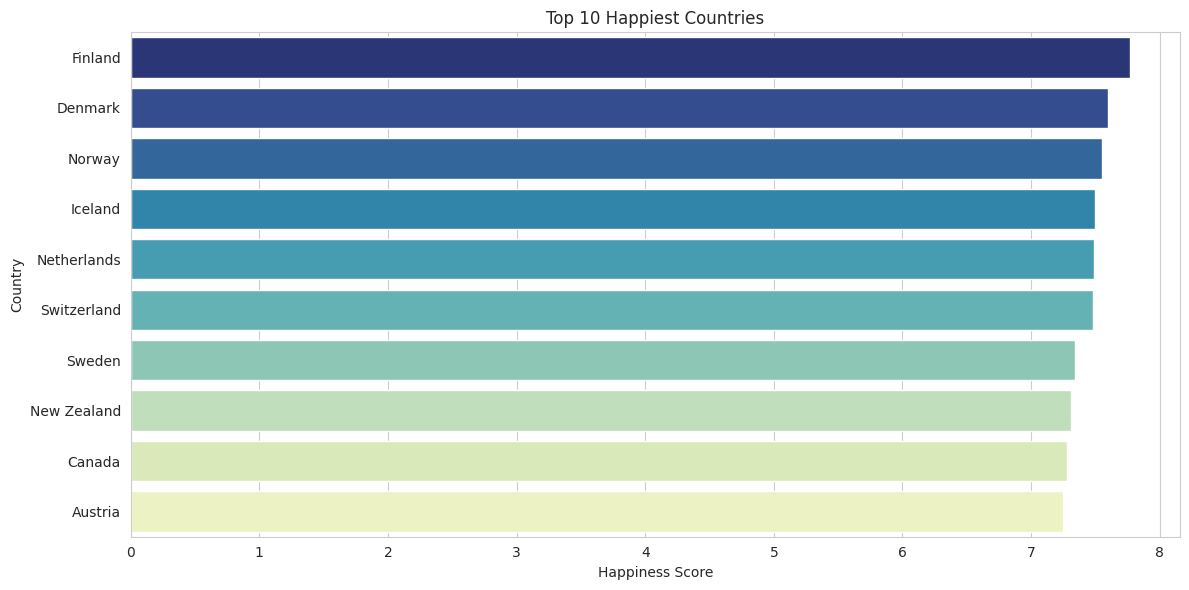

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='Score', y='Country', palette='YlGnBu_r')
plt.title('Top 10 Happiest Countries')
plt.xlabel('Happiness Score')
plt.tight_layout()
plt.show()

/tmp/ipykernel_557/4146896009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10, x='Score', y='Country', palette='OrRd')


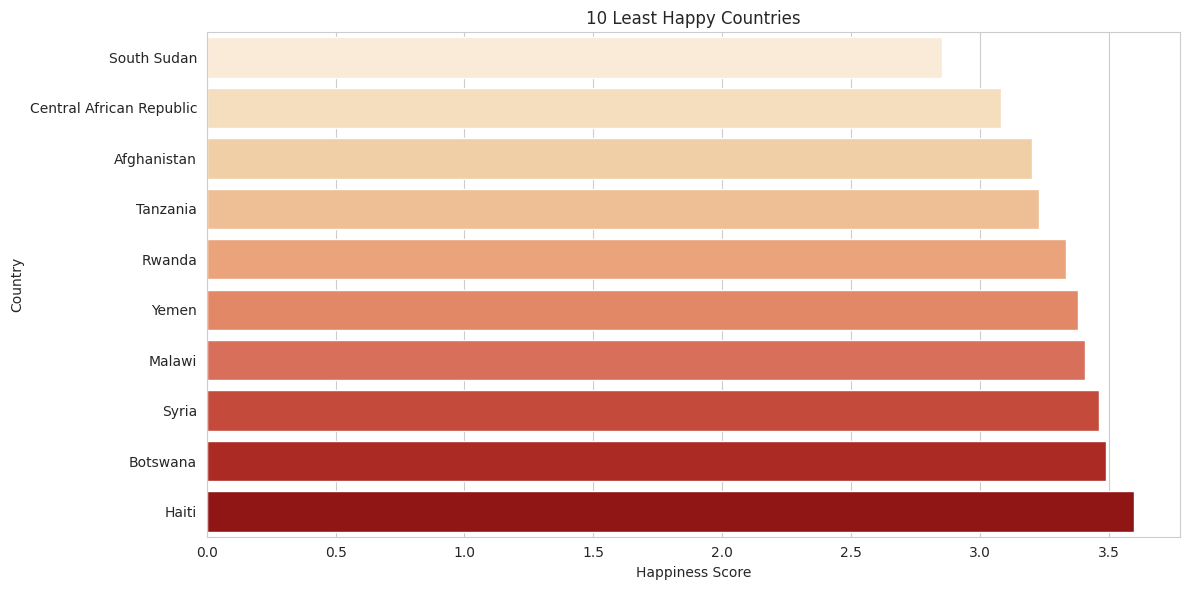

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(data=bottom10, x='Score', y='Country', palette='OrRd')
plt.title('10 Least Happy Countries')
plt.xlabel('Happiness Score')
plt.tight_layout()
plt.show()

## 5. Distribution of Happiness Scores

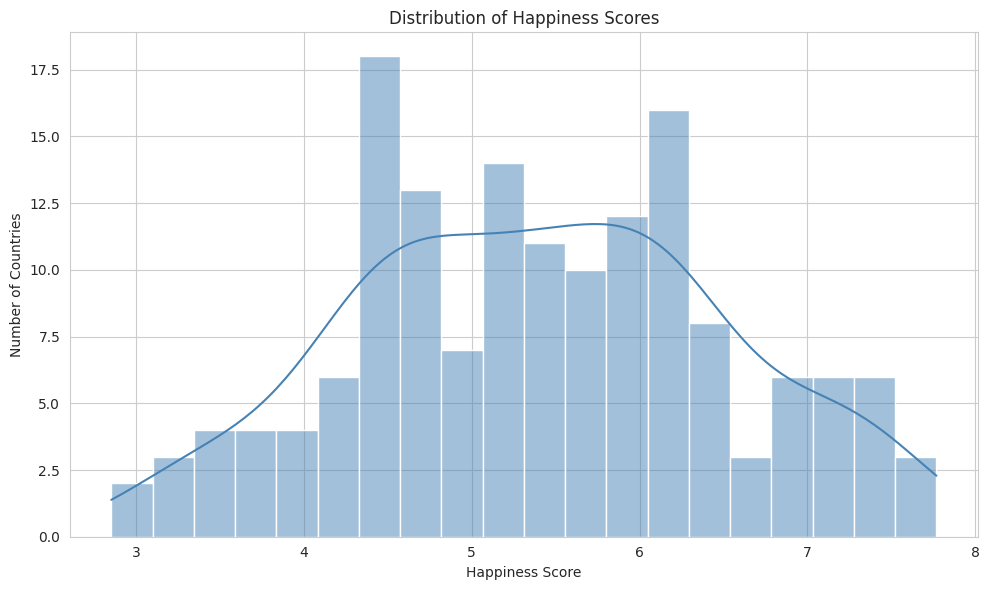

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Score'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Happiness Scores')
plt.xlabel('Happiness Score')
plt.ylabel('Number of Countries')
plt.tight_layout()
plt.show()

## 6. Correlation Between Factors

In [12]:
factor_cols = ['Score', 'GDP_per_capita', 'Social_support', 'Life_expectancy', 'Freedom', 'Generosity', 'Corruption']
corr = df[factor_cols].corr()
corr

,Score,GDP_per_capita,Social_support,Life_expectancy,Freedom,Generosity,Corruption
Score,1.000000,0.793883,0.777058,0.779883,0.566742,0.075824,0.385613
GDP_per_capita,0.793883,1.000000,0.754906,0.835462,0.379079,-0.079662,0.298920
Social_support,0.777058,0.754906,1.000000,0.719009,0.447333,-0.048126,0.181899
Life_expectancy,0.779883,0.835462,0.719009,1.000000,0.390395,-0.029511,0.295283
Freedom,0.566742,0.379079,0.447333,0.390395,1.000000,0.269742,0.438843
Generosity,0.075824,-0.079662,-0.048126,-0.029511,0.269742,1.000000,0.326538
Corruption,0.385613,0.298920,0.181899,0.295283,0.438843,0.326538,1.000000


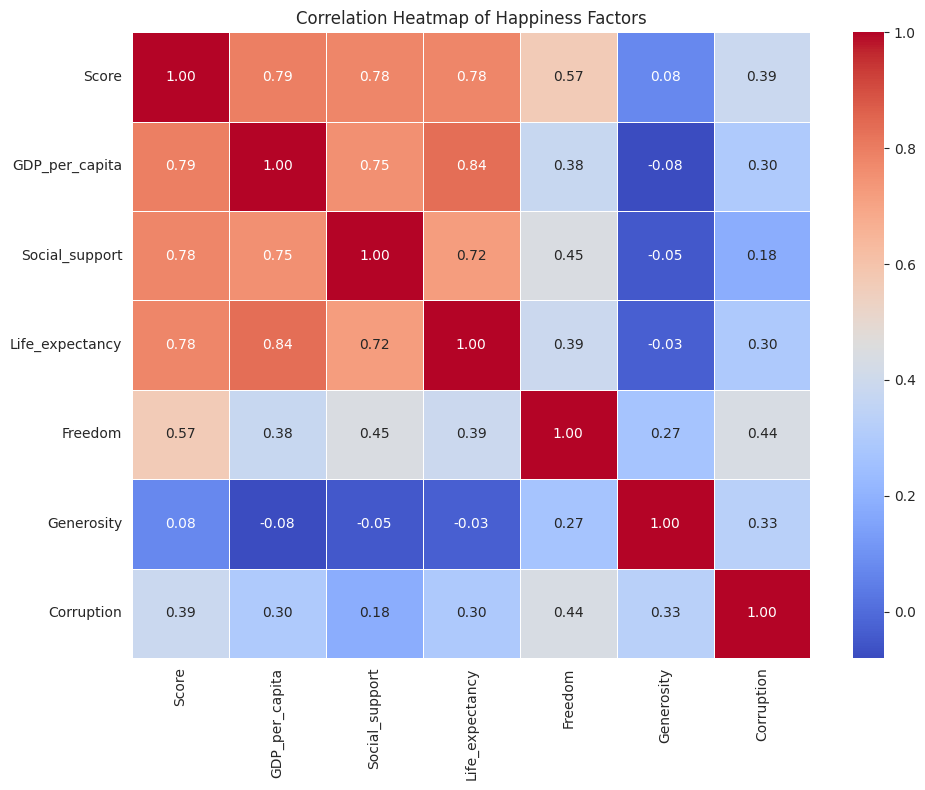

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Happiness Factors')
plt.tight_layout()
plt.show()

## 7. Happiness Score vs GDP per Capita

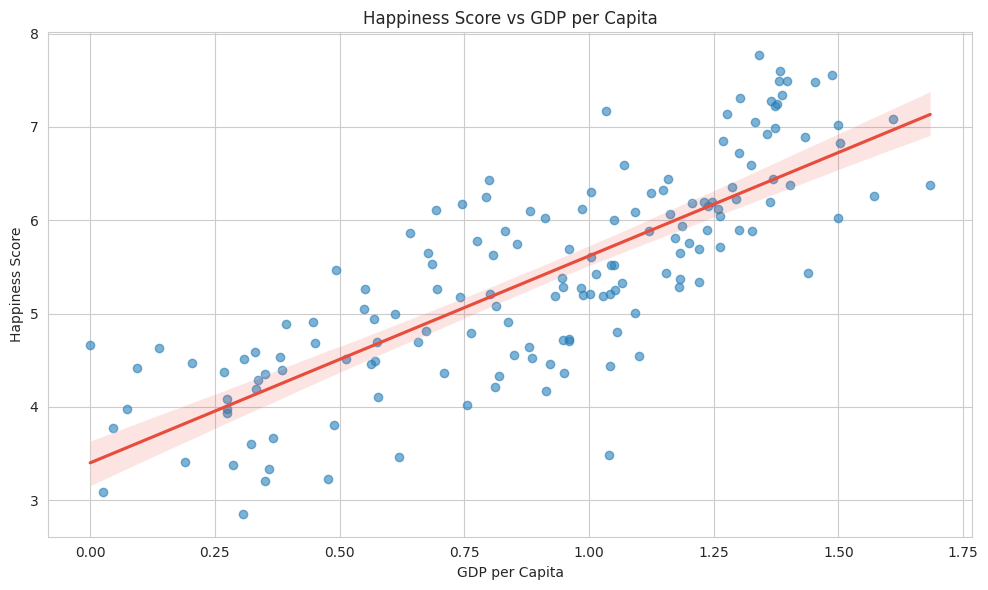

In [14]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='GDP_per_capita', y='Score', scatter_kws={'alpha': 0.6, 'color': '#2980b9'}, line_kws={'color': '#e74c3c'})
plt.title('Happiness Score vs GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()

## 8. Happiness Score vs Social Support

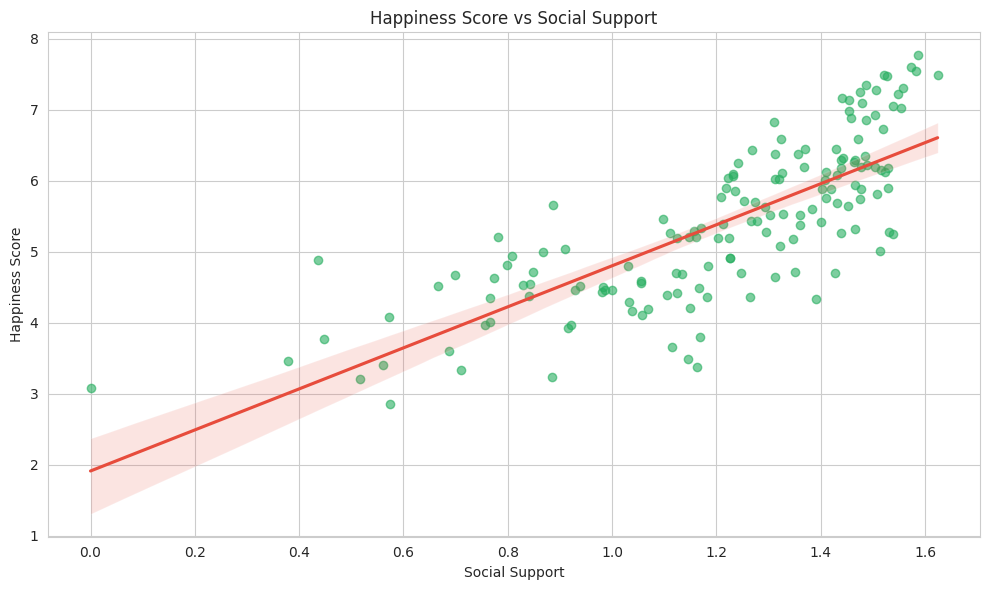

In [15]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Social_support', y='Score', scatter_kws={'alpha': 0.6, 'color': '#27ae60'}, line_kws={'color': '#e74c3c'})
plt.title('Happiness Score vs Social Support')
plt.xlabel('Social Support')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()

## 9. Happiness Score vs Life Expectancy

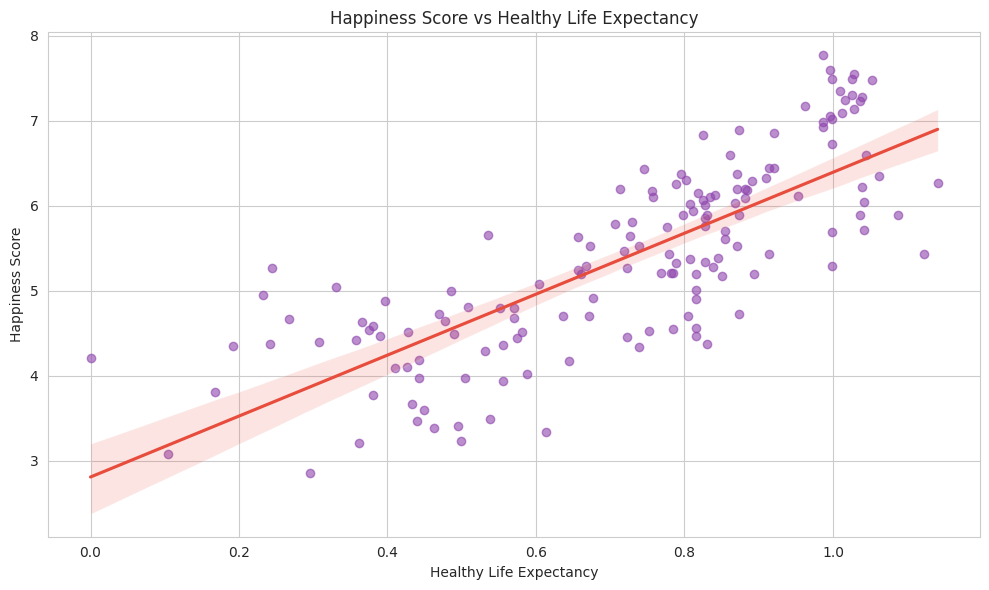

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Life_expectancy', y='Score', scatter_kws={'alpha': 0.6, 'color': '#8e44ad'}, line_kws={'color': '#e74c3c'})
plt.title('Happiness Score vs Healthy Life Expectancy')
plt.xlabel('Healthy Life Expectancy')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()

## 10. Multi-Factor Comparison for Top 10 Countries

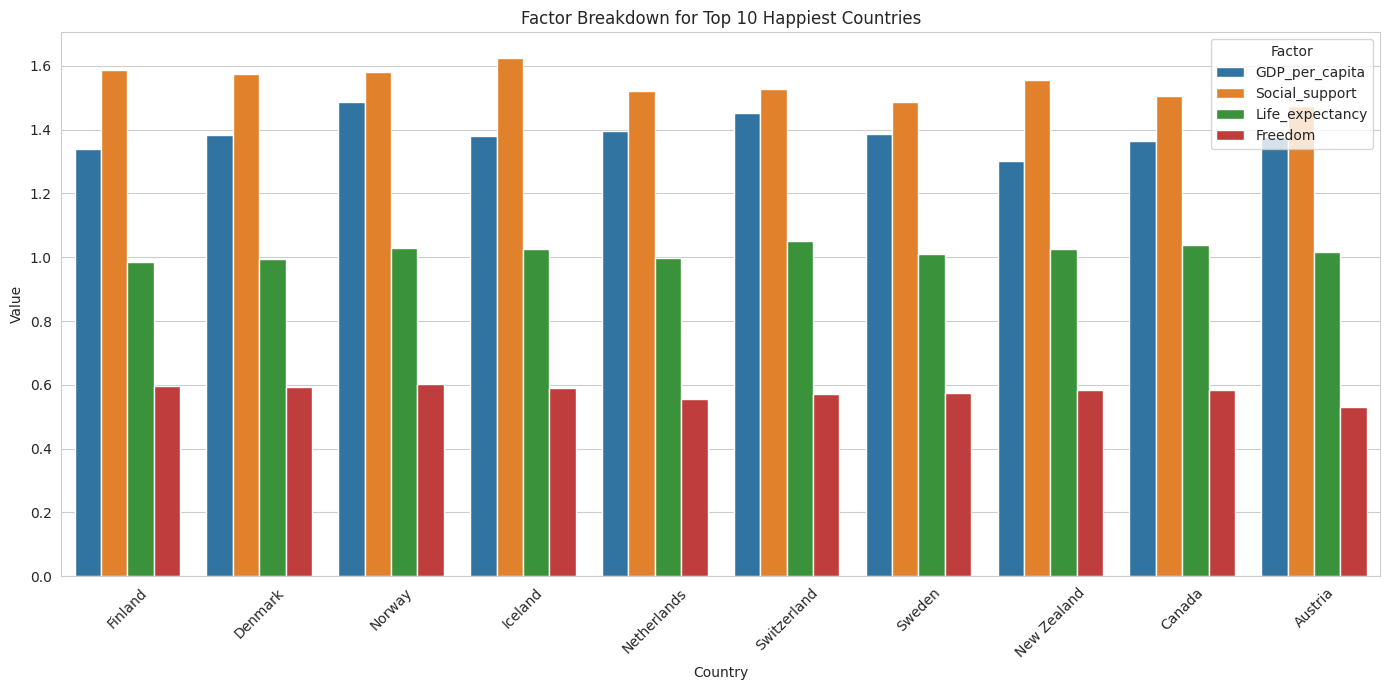

In [17]:
top10_melt = top10.melt(id_vars='Country', value_vars=['GDP_per_capita', 'Social_support', 'Life_expectancy', 'Freedom'], var_name='Factor', value_name='Value')

plt.figure(figsize=(14, 7))
sns.barplot(data=top10_melt, x='Country', y='Value', hue='Factor')
plt.xticks(rotation=45)
plt.title('Factor Breakdown for Top 10 Happiest Countries')
plt.tight_layout()
plt.show()

## 11. Pairwise Relationships Between Key Factors

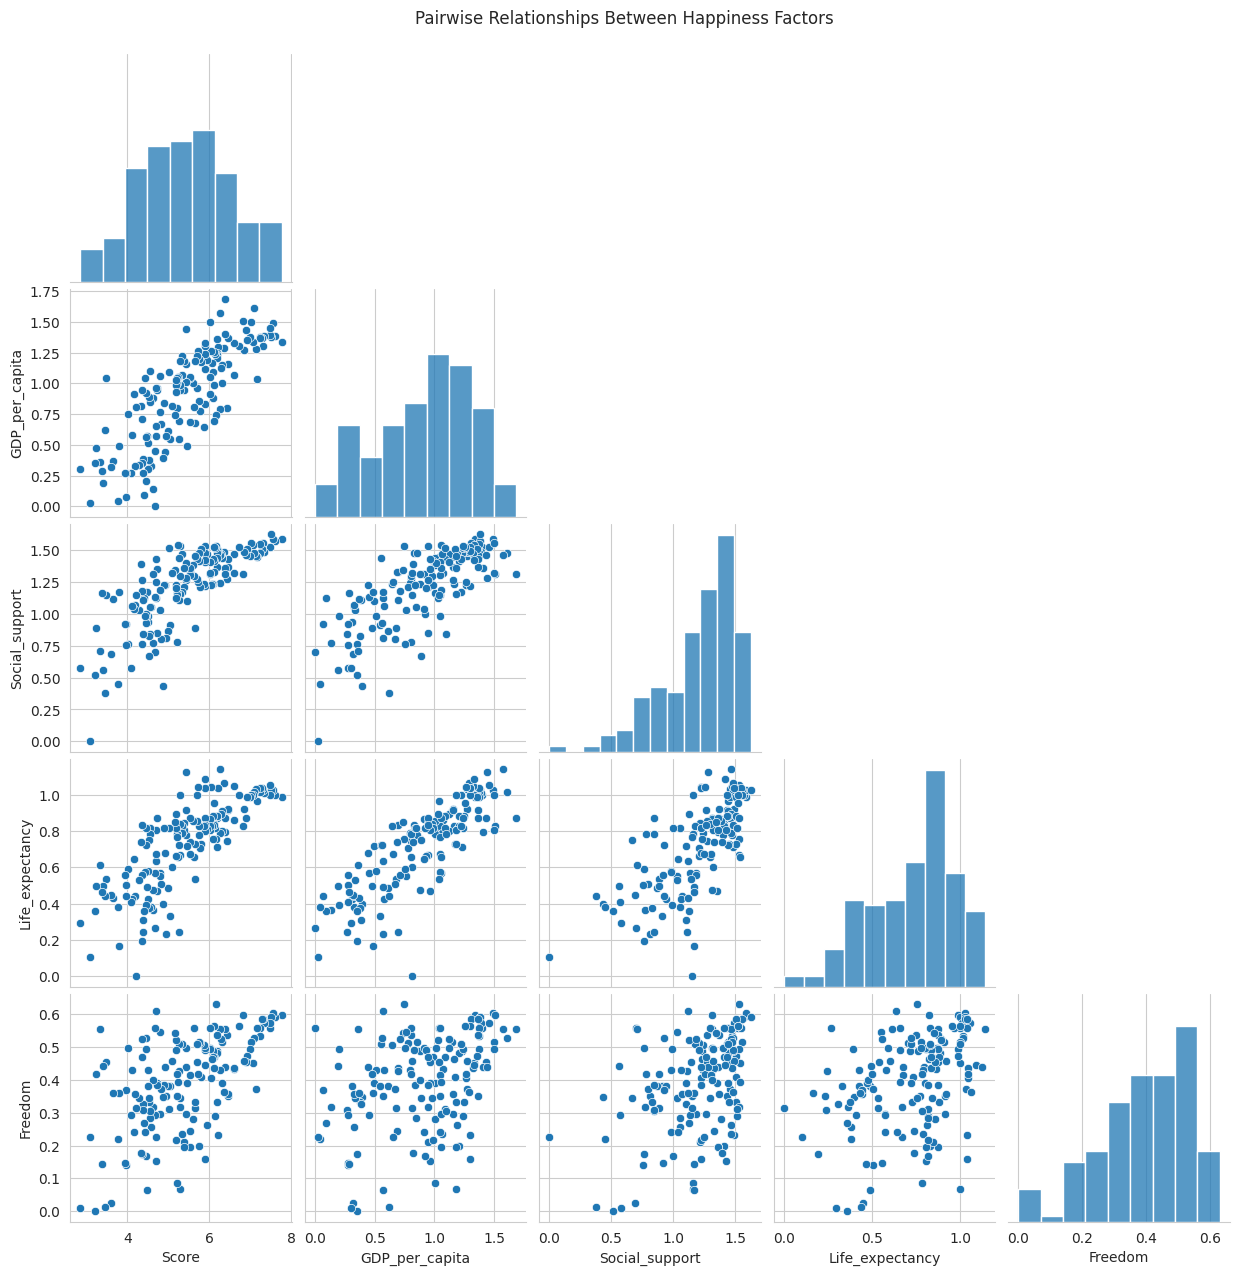

In [18]:
sns.pairplot(df[['Score', 'GDP_per_capita', 'Social_support', 'Life_expectancy', 'Freedom']], corner=True)
plt.suptitle('Pairwise Relationships Between Happiness Factors', y=1.02)
plt.show()

## 12. Freedom and Generosity Impact

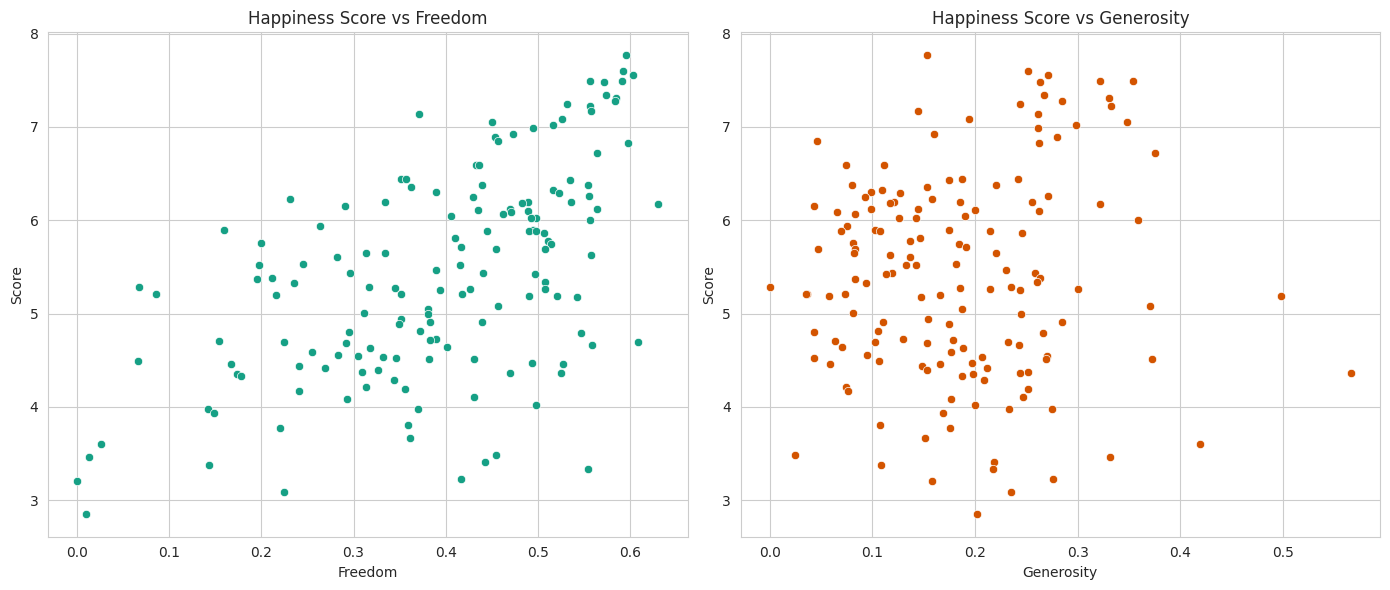

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df, x='Freedom', y='Score', ax=axes[0], color='#16a085')
axes[0].set_title('Happiness Score vs Freedom')

sns.scatterplot(data=df, x='Generosity', y='Score', ax=axes[1], color='#d35400')
axes[1].set_title('Happiness Score vs Generosity')

plt.tight_layout()
plt.show()

## 13. Perceptions of Corruption vs Happiness

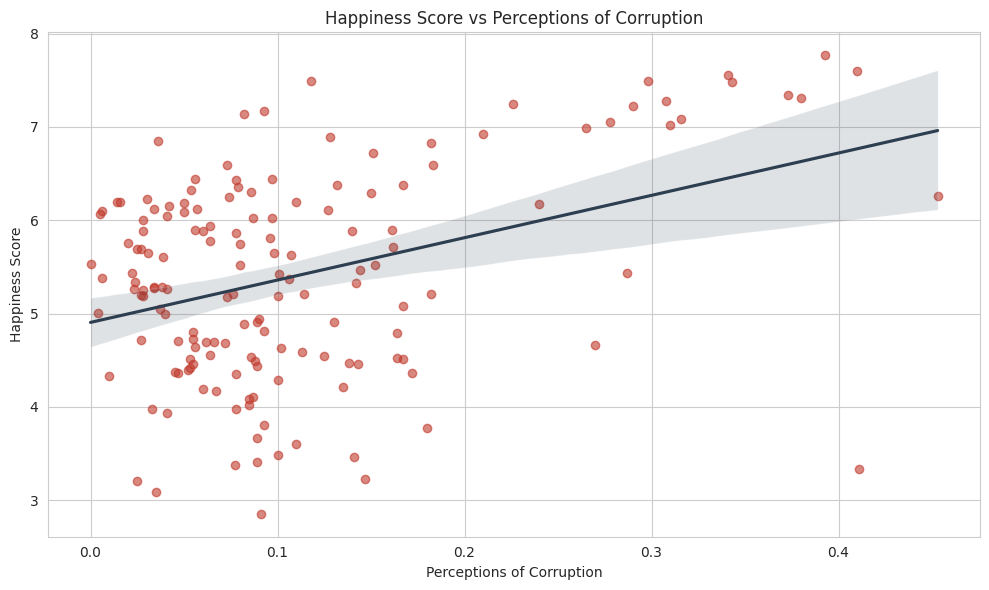

In [20]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Corruption', y='Score', scatter_kws={'alpha': 0.6, 'color': '#c0392b'}, line_kws={'color': '#2c3e50'})
plt.title('Happiness Score vs Perceptions of Corruption')
plt.xlabel('Perceptions of Corruption')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()

## 14. Summary of Correlations with Happiness Score

/tmp/ipykernel_557/3097148836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=score_corr.values, y=score_corr.index, palette='viridis')


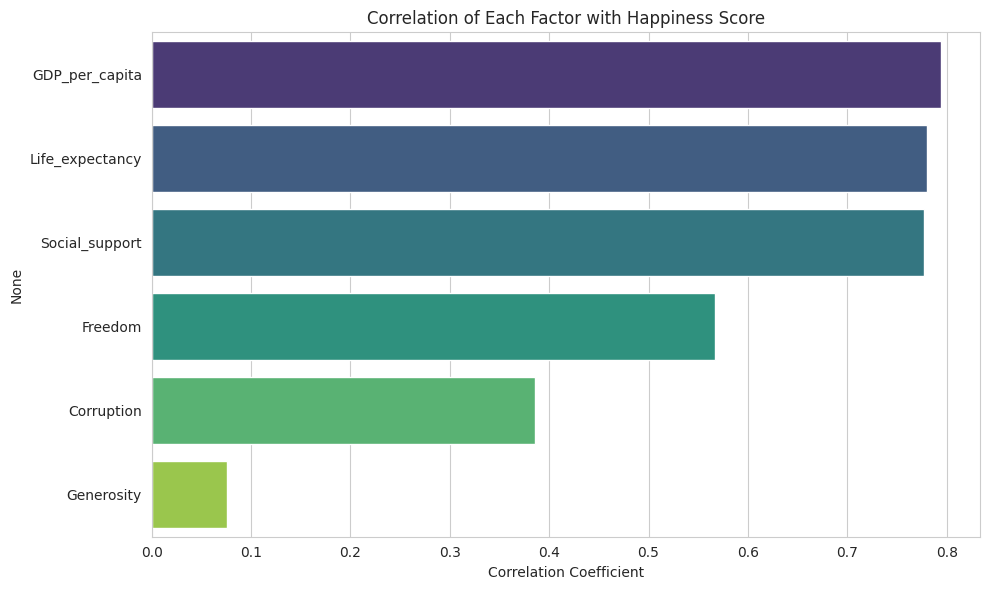

In [21]:
score_corr = corr['Score'].drop('Score').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=score_corr.values, y=score_corr.index, palette='viridis')
plt.title('Correlation of Each Factor with Happiness Score')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()